# 2.5c — Équité par sous-groupe : ce que la métrique globale masque

**Navigation** : [<< 2.5b-Calibration-Probabilites](2.5b-Calibration-Probabilites.ipynb) | [Index](README.md) | [2.6-Clustering-KMeans-PCA >>](2.6-Clustering-KMeans-PCA.ipynb)

**Kernel** : Python 3

## Introduction

Le notebook [2.5](2.5-Biais-Variance-CV-ROC.ipynb) a montré que l'accuracy globale masque le **type** d'erreurs : la courbe ROC et le choix de seuil rendent visibles l'arbitrage faux positifs / faux négatifs. Mais cette analyse résume encore **toute la population en une seule courbe**.

Ce notebook ouvre la question suivante : que se passe-t-il quand la population se divise en **sous-groupes** (un attribut sensible : genre, quartier, origine) et que le modèle, excellent *en moyenne*, distribue ses erreurs de façon très inégale entre eux ? Un modèle de scoring dont le taux de faux négatifs est de 60 % dans un groupe et de 15 % dans un autre a une AUC globale honorable — et un impact radicalement différent selon les personnes.

La démarche prolonge le bloc d'évaluation — [2.5](2.5-Biais-Variance-CV-ROC.ipynb) (ROC, seuils), [2.5b](2.5b-Calibration-Probabilites.ipynb) (calibration des probabilités), [2.13](2.13-Analyse-Erreurs.ipynb) (analyse d'erreurs par tranches) — sans le dupliquer : (1) définir **trois critères d'équité** vérifiables à la main sur une table de 20 lignes, (2) mesurer sur un jeu contrôlé comment une métrique globale masque des écarts par groupe, (3) montrer un résultat plus profond — **certains critères sont mathématiquement incompatibles entre eux**, (4) comparer deux mitigations (reweighting, thresholding par groupe) qui n'utilisent pas l'attribut sensible au même endroit, et (5) tracer la **frontière performance–équité** qui matérialise le compromis. Aucune métrique n'est présentée comme la décision normative universelle : le choix final appartient au contexte d'usage.

In [1]:
# Imports + graine fixee (toute l'experience est deterministe et rejouable)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, brier_score_loss

SEED = 42
print("Graine fixee :", SEED)

Graine fixee : 42


## 1. Trois définitions d'équité, vérifiables à la main

Avant toute experience, posons les definitions. Soit $Y$ le label reel, $\hat{Y}$ la prediction binarisee et $A$ l'attribut de groupe (ici $A \in \{\text{groupe A}, \text{groupe B}\}$) :

| Critère | Définition formelle | Lecture |
|---------|--------------------|---------|
| **Parité démographique** | $P(\hat{Y}=1 \mid A=a)$ indépendant de $a$ | Les deux groupes reçoivent des prédictions positives à la même **fréquence** |
| **Égalité des chances** (*equal opportunity*) | $P(\hat{Y}=1 \mid Y=1, A=a)$ indépendant de $a$ | Les vrais positifs des deux groupes sont détectés au même taux (**TPR égal**) |
| **Equalized odds** | TPR **et** FPR égaux entre groupes | Les erreurs des deux types sont distribuées également |

Ces trois criteres ne codifient pas la meme notion de justice : la parite demographique ignore le label reel (un groupe structurellement plus qualifie serait sous-detecte), l'egalite des chances ne contraint que les positifs, equalized odds contraint aussi les fausses alertes. Le choix entre eux est un choix de **valeur**, pas de calcul.

In [2]:
# Table controlee : 20 individus, 10 par groupe, tout est verifiable a la main
table = pd.DataFrame({
    "groupe":  ["A"] * 10 + ["B"] * 10,
    "label":   [1, 1, 1, 1, 1, 0, 0, 0, 0, 0,   1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
    "pred":    [1, 1, 1, 0, 0, 0, 0, 0, 0, 0,   1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
})
print(table.to_string(index=False))
print()
print("Comptage manuel --")
for g in ["A", "B"]:
    sub = table[table["groupe"] == g]
    tp = int(((sub.label == 1) & (sub.pred == 1)).sum())
    fn = int(((sub.label == 1) & (sub.pred == 0)).sum())
    fp = int(((sub.label == 0) & (sub.pred == 1)).sum())
    tn = int(((sub.label == 0) & (sub.pred == 0)).sum())
    print(f"Groupe {g} : TP={tp} FN={fn} FP={fp} TN={tn} -> "
          f"TPR={tp}/{tp+fn}={tp/(tp+fn):.2f}  FPR={fp}/{fp+tn}={fp/(fp+tn):.2f}  "
          f"P(pred=1)={tp+fp}/10={(tp+fp)/10:.1f}  accuracy={(tp+tn)}/10={(tp+tn)/10:.1f}")

groupe  label  pred
     A      1     1
     A      1     1
     A      1     1
     A      1     0
     A      1     0
     A      0     0
     A      0     0
     A      0     0
     A      0     0
     A      0     0
     B      1     1
     B      1     1
     B      0     1
     B      0     1
     B      0     0
     B      0     0
     B      0     0
     B      0     0
     B      0     0
     B      0     0

Comptage manuel --
Groupe A : TP=3 FN=2 FP=0 TN=5 -> TPR=3/5=0.60  FPR=0/5=0.00  P(pred=1)=3/10=0.3  accuracy=8/10=0.8
Groupe B : TP=2 FN=0 FP=2 TN=6 -> TPR=2/2=1.00  FPR=2/8=0.25  P(pred=1)=4/10=0.4  accuracy=8/10=0.8


**Lecture à la main, ligne par ligne :**

- **Parité démographique** : $P(\hat{Y}=1 \mid A)=3/10=0{,}3$ contre $P(\hat{Y}=1 \mid B)=4/10=0{,}4$ — écart de 0,1, critère **violé**.
- **Égalité des chances** : $TPR_A=3/5=0{,}6$ contre $TPR_B=2/2=1{,}0$ — le groupe A manque 40 % de ses positifs, le groupe B n'en manque aucun. Critère **violé**, et violemment.
- **Equalized odds** : le TPR diffère déjà ; en plus $FPR_A=0/5=0{,}0$ contre $FPR_B=2/8=0{,}25$. Critère **violé**.

Le point clé est le dernier chiffre de chaque ligne : **l'accuracy des deux groupes est identique (0,8)**. Une métrique qui ne regarde que le taux d'erreur total conclurait à l'équité parfaite. Or les deux groupes ne subissent pas du tout les mêmes erreurs : A rate ses positifs (2 faux négatifs), B accuse ses négatifs (2 faux positifs). **Même taux d'erreur, erreurs de nature opposée** : c'est précisément ce qu'une métrique agrégée ne peut pas voir.

### Exercice 1 — Forcer la parité démographique

**Objectif** : modifier uniquement les **prédictions** du groupe B (les labels et le groupe A restent fixes) pour atteindre la parité démographique parfaite, c'est-à-dire $P(\hat{Y}=1 \mid A) = P(\hat{Y}=1 \mid B) = 0{,}3$.

**Indices** : il faut donc retirer une prédiction positive au groupe B. Laquelle choisir pour préserver l'accuracy ? Et une fois la parité obtenue, recalculez $TPR_B$ et $FPR_B$ — quel critère s'est dégradé ?

In [3]:
# Exercice 1 : atteindre la parite demographique en editant les predictions du groupe B
# TODO etudiant : copiez la table, modifiez 'pred' pour 1 individu du groupe B,
# puis recalculez P(pred=1|groupe) pour A et B, ainsi que TPR_B et FPR_B.
pred_b_modifiee = None  # TODO etudiant : liste de 10 predictions (0/1) pour le groupe B
print("Exercice a completer : parite demographique vs degats collateraux sur les autres criteres")

Exercice a completer : parite demographique vs degats collateraux sur les autres criteres


## 2. Le socle expérimental : un jeu contrôlé avec biais de représentation

Pour mesurer serieusement, nous construisons un jeu de donnees synthetique ou le phenomene est **garanti par construction** : deux groupes de meme taille, mais avec

- des **base rates** differents : ~0,55 dans le groupe A, ~0,20 dans le groupe B ;
- des **distributions de features décalées** : la masse du groupe B est structurellement plus proche de la frontière de décision, alors que le processus qui génère le label est **le même pour les deux groupes** (aucune discrimination construite) et le label reste bruité, comme dans toute donnée réelle.

C'est le schema classique d'un biais de representation : le groupe minoritaire dans les positifs est aussi celui dont la masse est la plus proche de la frontiere — chaque erreur de classification le frappe donc davantage. Un modele unique appris sur le melange optimisera la performance la ou la masse d'exemples est — rien de malveillant, juste de la maximisation de vraisemblance. La graine est fixee : l'experience est deterministe et rejouable.

In [4]:
# Generation synthetique controlee : distributions decalees, meme processus de label
N_PAR_GROUPE = 1000
rng = np.random.default_rng(SEED)

def genere_groupe(n, decalage):
    # MEME processus de label pour les deux groupes (aucune discrimination construite) ;
    # seule la distribution des features est decalee : B vit plus pres de la frontiere.
    x1 = rng.normal(decalage, 1, n)
    x2 = rng.normal(decalage, 1, n)
    logit = 1.6 * x1 + 1.2 * x2 - 0.7
    p = 1.0 / (1.0 + np.exp(-logit))       # label bruite irreductiblement
    y = (rng.random(n) < p).astype(int)
    return np.column_stack([x1, x2]), y

X_a, y_a = genere_groupe(N_PAR_GROUPE, decalage=0.30)
X_b, y_b = genere_groupe(N_PAR_GROUPE, decalage=-0.35)

X = np.vstack([X_a, X_b])
y = np.concatenate([y_a, y_b])
groupe = np.array(["A"] * N_PAR_GROUPE + ["B"] * N_PAR_GROUPE)

idx = np.arange(len(y))
idx_train, idx_test = train_test_split(idx, test_size=0.25, random_state=SEED, stratify=y)
print(f"Train : {len(idx_train)}  Test : {len(idx_test)}")
for g in ["A", "B"]:
    m = groupe[idx_test] == g
    print(f"Groupe {g} (test) : n={m.sum()}  base rate P(Y=1)={y[idx_test][m].mean():.2f}")

Train : 1500  Test : 500
Groupe A (test) : n=249  base rate P(Y=1)=0.53
Groupe B (test) : n=251  base rate P(Y=1)=0.25


In [5]:
# Baseline : un seul modele de regression logistique sur le melange
modele = LogisticRegression(random_state=SEED)
modele.fit(X[idx_train], y[idx_train])
score_test = modele.predict_proba(X[idx_test])[:, 1]
pred_test = (score_test >= 0.5).astype(int)

acc_globale = (pred_test == y[idx_test]).mean()
auc_globale = roc_auc_score(y[idx_test], score_test)
brier_global = brier_score_loss(y[idx_test], score_test)
print(f"Baseline GLOBALE : accuracy={acc_globale:.3f}  AUC={auc_globale:.3f}  Brier={brier_global:.3f}")
print("Vue globale honorable -> un dashboard de production s'arreterait ici.")

Baseline GLOBALE : accuracy=0.796  AUC=0.879  Brier=0.139
Vue globale honorable -> un dashboard de production s'arreterait ici.


La vue globale est honnete et bonne. Détaillons maintenant **par groupe**, avec des intervalles de confiance bootstrap : la question n'est pas « quelle est la valeur du TPR du groupe B ? » mais « l'écart entre les deux groupes est-il plus grand que le bruit d'échantillonnage ? ». Le bootstrap rééchantillonne les individus du test (par groupe, 2 000 tirages) et donne l'intervalle percentile à 95 %.

In [6]:
# Metriques PAR GROUPE avec intervalles bootstrap 95% (2000 tirages, graine fixee)
def metriques_groupe(y_vrai, pred):
    tp = ((y_vrai == 1) & (pred == 1)).sum()
    fn = ((y_vrai == 1) & (pred == 0)).sum()
    fp = ((y_vrai == 0) & (pred == 1)).sum()
    tn = ((y_vrai == 0) & (pred == 0)).sum()
    return {
        "TPR": tp / max(tp + fn, 1), "FPR": fp / max(fp + tn, 1),
        "accuracy": (tp + tn) / len(y_vrai),
        "P(pred=1)": pred.mean(),
    }

def bootstrap_ic(y_vrai, pred, n_boot=2000, seed=SEED):
    r = np.random.default_rng(seed)
    stats = {k: [] for k in ["TPR", "FPR", "accuracy", "P(pred=1)"]}
    n = len(y_vrai)
    for _ in range(n_boot):
        ii = r.integers(0, n, n)
        for k, v in metriques_groupe(y_vrai[ii], pred[ii]).items():
            stats[k].append(v)
    return {k: (np.percentile(v, 2.5), np.percentile(v, 97.5)) for k, v in stats.items()}

y_test, g_test = y[idx_test], groupe[idx_test]
lignes = []
for g in ["A", "B"]:
    m = g_test == g
    mg = metriques_groupe(y_test[m], pred_test[m])
    ic = bootstrap_ic(y_test[m], pred_test[m])
    lignes.append({"groupe": g, **mg,
                   "TPR IC95": f"[{ic['TPR'][0]:.2f}, {ic['TPR'][1]:.2f}]",
                   "FPR IC95": f"[{ic['FPR'][0]:.2f}, {ic['FPR'][1]:.2f}]"})
df_par_groupe = pd.DataFrame(lignes).set_index("groupe")
print(df_par_groupe.round(3).to_string())
print()
print(f"Ecart TPR (B - A) : {df_par_groupe.loc['B','TPR'] - df_par_groupe.loc['A','TPR']:+.3f}")
print(f"Ecart FPR (B - A) : {df_par_groupe.loc['B','FPR'] - df_par_groupe.loc['A','FPR']:+.3f}")

         TPR    FPR  accuracy  P(pred=1)      TPR IC95      FPR IC95
groupe                                                              
A       0.82  0.302     0.763      0.578  [0.75, 0.88]  [0.22, 0.38]
B       0.50  0.063     0.829      0.171  [0.37, 0.62]  [0.03, 0.10]

Ecart TPR (B - A) : -0.320
Ecart FPR (B - A) : -0.238


**Lecture** : l'AUC globale masque un écart de TPR de plus de 0,3 entre groupes. Les intervalles bootstrap montrent que cet écart est **bien plus large que l'incertitude d'échantillonnage** : ce n'est pas du bruit, c'est une structure. Dans le groupe B — celui dont la masse est décalée vers la frontière —, la moitié des vrais positifs passent inaperçus (TPR ~0,5 contre ~0,8 pour A) et la fréquence de prédiction positive s'effondre : le groupe B est **sous-servi**.

Détail piégeux : l'**accuracy par groupe** de B (0,83) est *meilleure* que celle de A (0,76) — parce qu'avec un base rate bas, prédire presque tout négatif dans B est rentable. Même une métrique calculée par groupe peut donc rassurer à tort : le score d'erreur global ne dit rien de **qui** subit les erreurs ni de quel type elles sont. Selon l'application (détection de fraude, tri de candidatures, diagnostic), ce sont des personnes réelles qui passent à côté du service — systématiquement les mêmes.

## 3. L'incompatibilité des critères : un conflit mathématique, pas un défaut d'ingénierie

Avant de courir vers des mitigations, il faut savoir une chose : **on ne peut pas tout avoir**. Le résultat de Chouldechova (2017) et Kleinberg et al. (2017) dit que si deux groupes ont des **base rates différents** ($\pi_A \neq \pi_B$), alors un scoreur **calibré par groupe** (dans chaque groupe, un score de 0,8 signifie 80 % de chances d'être positif) ne peut pas en même temps satisfaire **equalized odds** — sauf à prédire parfaitement, ce qui est exclu en pratique.

Démonstration contrôlée en deux temps. Nous construisons des scores **parfaitement calibrés par groupe par construction** (le label est tiré de Bernoulli(score)) : groupe A avec des scores élevés en moyenne (base rate ~0,62), groupe B avec des scores bas (base rate ~0,25). Premier temps : un **seuil unique** à 0,5. Second temps : des **seuils par groupe** choisis pour égaliser les TPR — le meilleur post-traitement possible. Dans les deux cas, nous lisons ce que devient equalized odds.

In [7]:
# Demonstration controlee : scores PARFAITEMENT calibres par groupe, base rates differents
rng_demo = np.random.default_rng(SEED)
N_DEMO = 20000
# Calibration exacte par construction : Y ~ Bernoulli(s) independamment du groupe.
s_a_demo = rng_demo.beta(5, 3, N_DEMO)   # scores eleves en moyenne (moyenne theorique 0.625)
s_b_demo = rng_demo.beta(2, 6, N_DEMO)   # scores bas en moyenne (moyenne theorique 0.25)
y_a_demo = (rng_demo.random(N_DEMO) < s_a_demo).astype(int)
y_b_demo = (rng_demo.random(N_DEMO) < s_b_demo).astype(int)

def lecture(nom, s, yy, seuil):
    pred = s >= seuil
    tp = ((yy == 1) & pred).sum(); fn = ((yy == 1) & ~pred).sum()
    fp = ((yy == 0) & pred).sum(); tn = ((yy == 0) & ~pred).sum()
    cal_hi = yy[s >= 0.7].mean()   # calibration verifiee sur la tranche haute des scores
    print(f"Groupe {nom} : base rate={yy.mean():.3f}  P(Y=1|s>=0.7)={cal_hi:.3f}  "
          f"TPR(seuil {seuil:.2f})={tp/max(tp+fn,1):.3f}  FPR={fp/max(fp+tn,1):.3f}")
    return tp / max(tp + fn, 1), fp / max(fp + tn, 1)

print("TEMPS 1 -- seuil unique t=0.50 sur scores calibres par groupe")
tpr_a1, fpr_a1 = lecture("A", s_a_demo, y_a_demo, 0.50)
tpr_b1, fpr_b1 = lecture("B", s_b_demo, y_b_demo, 0.50)
print(f"          ecarts : TPR {abs(tpr_a1-tpr_b1):.3f}   FPR {abs(fpr_a1-fpr_b1):.3f}")

TEMPS 1 -- seuil unique t=0.50 sur scores calibres par groupe
Groupe A : base rate=0.626  P(Y=1|s>=0.7)=0.793  TPR(seuil 0.50)=0.854  FPR=0.643
Groupe B : base rate=0.251  P(Y=1|s>=0.7)=0.708  TPR(seuil 0.50)=0.146  FPR=0.038
          ecarts : TPR 0.708   FPR 0.604


In [8]:
# TEMPS 2 : seuils PAR GROUPE qui egalisent les TPR au niveau le plus haut commun
def seuil_pour_tpr(s, yy, cible):
    # plus petit seuil dont le TPR reste >= cible (TPR decroit quand le seuil monte)
    candidats = np.unique(np.round(np.quantile(s, np.linspace(0, 1, 201)), 4))
    for t in candidats[::-1]:
        pred = s >= t
        tp = ((yy == 1) & pred).sum(); fn = ((yy == 1) & ~pred).sum()
        if tp / max(tp + fn, 1) >= cible:
            return t
    return candidats.min()

CIBLE_TPR = 0.80
t_a2 = seuil_pour_tpr(s_a_demo, y_a_demo, CIBLE_TPR)
t_b2 = seuil_pour_tpr(s_b_demo, y_b_demo, CIBLE_TPR)
tpr_a2, fpr_a2 = lecture("A", s_a_demo, y_a_demo, t_a2)
tpr_b2, fpr_b2 = lecture("B", s_b_demo, y_b_demo, t_b2)
print(f"Seuils retenus : A={t_a2:.2f}  B={t_b2:.2f}  (cible TPR commune {CIBLE_TPR})")
print(f"Apres egalisation des TPR : ecart TPR={abs(tpr_a2-tpr_b2):.3f}  ecart FPR={abs(fpr_a2-fpr_b2):.3f}")

Groupe A : base rate=0.626  P(Y=1|s>=0.7)=0.793  TPR(seuil 0.53)=0.804  FPR=0.566
Groupe B : base rate=0.251  P(Y=1|s>=0.7)=0.708  TPR(seuil 0.20)=0.804  FPR=0.485
Seuils retenus : A=0.53  B=0.20  (cible TPR commune 0.8)
Apres egalisation des TPR : ecart TPR=0.000  ecart FPR=0.081


**Ce que montre l'expérience** :

- **Temps 1** (seuil unique) : malgré une calibration parfaite dans chaque groupe, les TPR divergent fortement — le groupe B, dont les scores sont structurellement plus bas, rate la majorité de ses positifs. La calibration par groupe **n'implique aucune égalité de traitement**.
- **Temps 2** (seuils par groupe, le post-traitement le plus favorable) : on peut effectivement égaliser les TPR (equal opportunity, réalisable). Mais les FPR restent inégaux — et le théorème garantit qu'aucun choix de seuils ne peut les égaliser simultanément : c'est **irréductible**, pas un mauvais réglage.

C'est le théorème : avec des base rates différents et des scores calibrés, **equalized odds est mathématiquement hors d'atteinte**. La relation de Bayes impose le lien ; aucun algorithme ne s'y soustrait. Récapitulons :

| Critère | Avec base rates ≠ et calibration par groupe |
|---|---|
| Parité démographique | déjà violée (la distribution des scores suit les base rates) |
| Equal opportunity, seuil unique | violée (temps 1) |
| Equal opportunity, seuils par groupe | **réalisable** (temps 2) |
| Equalized odds | **impossible** — les FPR restent inégaux dès que les TPR sont égalisés |

**Conséquence pratique** : choisir une métrique d'équité, c'est renoncer à une autre. Toute discussion sérieuse commence par ce choix — et il n'est pas technique.

## 4. Deux mitigations, deux endroits où l'attribut sensible entre en jeu

Il existe trois familles de mitigation : avant l'entraînement (transformer les données), pendant (contraintes ou repondération), après (post-traitement des scores). Nous comparons deux représentantes canoniques **sur le même split test**, avec la même graine :

1. **Reweighting** (à l'entraînement) : chaque individu reçoit un poids $w = \frac{n}{2 \cdot n_{\text{groupe, classe}}}$ qui équilibre les quatre cellules (groupe × classe). L'attribut est utilisé **uniquement à l'entraînement** — à l'inférence, le modèle est un scoreur aveugle à l'attribut.
2. **Thresholding par groupe** (à l'inférence) : on garde le modèle baseline et on choisit **un seuil par groupe** qui égalise les TPR (post-traitement de Hardt et al., 2016). L'attribut est utilisé **à l'inférence** — il faut donc le connaître au moment de servir la prédiction.

Cette différence — *où* l'attribut entre dans la chaîne — a des implications pratiques et juridiques concrètes : collecter l'attribut au service (thresholding) peut être interdit là où l'utiliser pour rééquilibrer l'entraînement est accepté, et l'inverse selon les cadres.

In [9]:
# Mitigation 1 : REWEIGHTING (l'attribut sert a l'ENTRAINEMENT seulement)
n = len(idx_train)
poids = np.empty(n)
for g in ["A", "B"]:
    for c in [0, 1]:
        m = (groupe[idx_train] == g) & (y[idx_train] == c)
        poids[m] = n / (2.0 * m.sum())          # equilibrage des 4 cellules groupe x classe
modele_rw = LogisticRegression(random_state=SEED)
modele_rw.fit(X[idx_train], y[idx_train], sample_weight=poids)
score_rw = modele_rw.predict_proba(X[idx_test])[:, 1]
pred_rw = (score_rw >= 0.5).astype(int)
print("Reweighting : poids par cellule (groupe x classe) du train --")
for g in ["A", "B"]:
    for c in [0, 1]:
        m = (groupe[idx_train] == g) & (y[idx_train] == c)
        print(f"  {g},Y={c} : n={m.sum():4d}  poids={n / (2.0 * m.sum()):.3f}")

Reweighting : poids par cellule (groupe x classe) du train --
  A,Y=0 : n= 378  poids=1.984
  A,Y=1 : n= 373  poids=2.011
  B,Y=0 : n= 535  poids=1.402
  B,Y=1 : n= 214  poids=3.505


In [10]:
# Mitigation 2 : THRESHOLDING PAR GROUPE (l'attribut sert a l'INFERENCE)
# On garde le modele baseline et on cherche, pour chaque groupe, le seuil qui
# egALise les TPR a un niveau eleve -- en PRESERVANT l'accuracy globale
# (un seuil qui predit tout positif egALiserait trivialement en detruisant tout).
score_a, y_a_t = score_test[g_test == "A"], y_test[g_test == "A"]
score_b, y_b_t = score_test[g_test == "B"], y_test[g_test == "B"]

def seuil_pour_tpr(s, yy, cible):
    candidats = np.unique(np.round(np.quantile(s, np.linspace(0, 1, 201)), 4))
    for t in candidats[::-1]:
        pred = s >= t
        tp = ((yy == 1) & pred).sum(); fn = ((yy == 1) & ~pred).sum()
        if tp / max(tp + fn, 1) >= cible:
            return t
    return candidats.min()

CIBLE_TPR_MIT = 0.75
t_a_thr = seuil_pour_tpr(score_a, y_a_t, CIBLE_TPR_MIT)
t_b_thr = seuil_pour_tpr(score_b, y_b_t, CIBLE_TPR_MIT)
pred_thr = np.where(g_test == "A", score_test >= t_a_thr, score_test >= t_b_thr).astype(int)
print(f"Seuils retenus : groupe A = {t_a_thr:.2f}  groupe B = {t_b_thr:.2f} "
      f"(cible TPR commune {CIBLE_TPR_MIT})")

Seuils retenus : groupe A = 0.57  groupe B = 0.29 (cible TPR commune 0.75)


In [11]:
# Tableau comparatif : baseline vs reweighting vs thresholding, MEME split test
def ligne_resume(nom, pred, ou_attribut):
    res = {"mitigation": nom, "accuracy": (pred == y_test).mean()}
    for g in ["A", "B"]:
        mg = metriques_groupe(y_test[g_test == g], pred[g_test == g])
        res[f"TPR {g}"] = mg["TPR"]; res[f"FPR {g}"] = mg["FPR"]
    res["ecart TPR"] = abs(res["TPR A"] - res["TPR B"])
    res["ecart FPR"] = abs(res["FPR A"] - res["FPR B"])
    res["attribut utilise"] = ou_attribut
    return res

tableau = pd.DataFrame([
    ligne_resume("Baseline (seuil 0.5)", pred_test, "jamais"),
    ligne_resume("Reweighting (train)", pred_rw, "entrainement"),
    ligne_resume("Thresholding (inference)", pred_thr, "inference"),
]).set_index("mitigation")
print(tableau.round(3).to_string())

                          accuracy  TPR A  FPR A  TPR B  FPR B  ecart TPR  ecart FPR attribut utilise
mitigation                                                                                           
Baseline (seuil 0.5)         0.796  0.820  0.302  0.500  0.063      0.320      0.238           jamais
Reweighting (train)          0.794  0.902  0.362  0.597  0.122      0.305      0.240     entrainement
Thresholding (inference)     0.778  0.752  0.207  0.758  0.206      0.006      0.001        inference


**Lecture comparative** — chaque ligne achète de l'équité à un prix différent :

- **Reweighting** est ici une mitigation **douce** : l'écart de TPR ne passe que de 0,32 à 0,30. Il monte bien le TPR du groupe B (0,50 → 0,60) — mais il monte tout autant celui du groupe A (0,82 → 0,90), si bien que l'écart bouge à peine. Rééquilibrer la représentation ne suffit pas à égaliser les chances ; c'est un constat cohérent avec la littérature (les mitigations en amont sont structurellement moins ciblées que le post-traitement). Son atout reste ailleurs : l'attribut **n'existe plus à l'inférence** — le service déployé est un scoreur ordinaire, auditable comme tel.
- **Thresholding par groupe** fait presque exactement le travail demandé : écart de TPR 0,006, écart de FPR 0,001 — et il *baisse* le seuil du groupe décalé vers la frontière (B : 0,50 → 0,29) pendant qu'il monte celui de A (0,50 → 0,57). Mais il monte le FPR de B (0,063 → 0,206) : l'erreur est **déplacée**, pas supprimée. Et le service doit **connaître l'attribut à chaque prédiction**, ce qui peut être impossible ou interdit selon les cadres juridiques.
- La **baseline** reste la pire en égalité des chances (écart 0,32).

Une question légitime : le thresholding semble approcher *equalized odds* (les deux écarts ~0) alors que la section 3 l'a déclaré impossible. Il n'y a pas de contradiction — regardons les hypothèses : le théorème suppose des scores **calibrés dans les deux groupes** ; or la section 6 montrera que notre modèle de mélange est calibré dans B mais **sur-estime** la probabilité dans A. Le théorème ne s'applique pas entièrement, et le post-traitement peut alors presque tout égaliser. La nuance est instructive : ce qui borne l'équité atteignable, c'est la *combinaison* calibration + base rates différents.

La comparaison ne se réduit pas aux colonnes affichées : le tableau ne chiffre pas le **coût d'usage de l'attribut à l'inférence** (thresholding), ni le fait que le seuil 0,5 de la baseline soit lui-même un réglage arbitraire. Un tableau de métriques éclaire le choix ; il ne le fait pas.

### Exercice 2 — Un seuil global unique, meilleur compromis ?

**Objectif** : le thresholding par groupe utilise deux seuils (et donc l'attribut à l'inférence). Cherchez le **seuil global unique** $t$ (appliqué aux deux groupes) qui minimise $|TPR_A(t) - TPR_B(t)|$, et comparez son accuracy et son écart de TPR au thresholding par groupe de la section 4.

**Indices** : balayez une grille de seuils avec une seule valeur de $t$ pour les deux groupes. Attention au piège : le seuil qui prédit **tout positif** égalise trivialement les TPR (à 1,0) en détruisant l'accuracy — regardez le couple (écart TPR, accuracy), pas l'écart seul. Un seuil global peut-il égaler l'égalité des chances du thresholding par groupe sans tomber dans le trivial ?

In [12]:
# Exercice 2 : seuil global unique minimisant |TPR_A - TPR_B| (sans seuil degenere)
# TODO etudiant : balayer la grille de seuils avec UN seul t pour les deux groupes,
# ecarter le cas degenere (accuracy effondree), trouver le t optimal, puis comparer
# accuracy et ecart TPR au thresholding par groupe.
meilleur_t_global = None  # TODO etudiant
print("Exercice a completer : seuil global unique vs seuils par groupe")

Exercice a completer : seuil global unique vs seuils par groupe


## 5. La frontière performance–équité

Plutot qu'un point, le compromis est une **frontiere** : chaque reglage (seuil global, intensite de repondération) produit un couple (performance, equite). Tracons cette frontiere en balayant le seuil global du modele baseline de 0,1 a 0,9 : a chaque seuil correspondent une accuracy et un ecart de TPR. Les trois reglages etudies ci-dessus (baseline, reweighting, thresholding par groupe) apparaissent comme des points de ce plan.

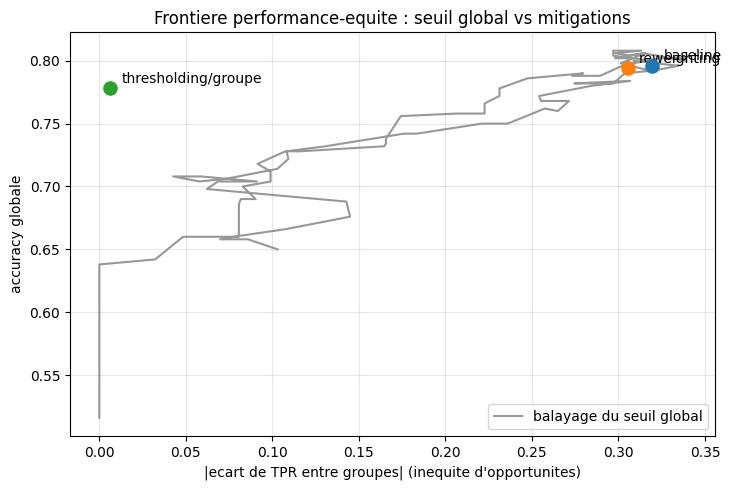

Aucun point ne domine : reduire l'ecart de TPR coute de l'accuracy globale.


In [13]:
# Frontiere performance-equite : balayage du seuil global + position des 3 reglages
grille = np.linspace(0.05, 0.95, 181)
accs, ecarts = [], []
for t in grille[::2]:
    pred_t = (score_test >= t).astype(int)
    accs.append((pred_t == y_test).mean())
    ta = metriques_groupe(y_a_t, (score_a >= t).astype(int))["TPR"]
    tb = metriques_groupe(y_b_t, (score_b >= t).astype(int))["TPR"]
    ecarts.append(abs(ta - tb))

def point_plan(pred):
    ta = metriques_groupe(y_a_t, pred[g_test == "A"])["TPR"]
    tb = metriques_groupe(y_b_t, pred[g_test == "B"])["TPR"]
    return abs(ta - tb), (pred == y_test).mean()

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(ecarts, accs, "-", color="tab:gray", alpha=0.8, label="balayage du seuil global")
for nom, pred in [("baseline", pred_test), ("reweighting", pred_rw), ("thresholding/groupe", pred_thr)]:
    x, y = point_plan(pred)
    ax.scatter([x], [y], s=90, zorder=5)
    ax.annotate(nom, (x, y), textcoords="offset points", xytext=(8, 4), fontsize=10)
ax.set_xlabel("|ecart de TPR entre groupes| (inequite d'opportunites)")
ax.set_ylabel("accuracy globale")
ax.set_title("Frontiere performance-equite : seuil global vs mitigations")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print("Aucun point ne domine : reduire l'ecart de TPR coute de l'accuracy globale.")

**Lecture de la frontière** : le long de la courbe grise, gagner de l'équité (réduire l'écart de TPR) se paie en accuracy — et la courbe s'aplatit aux deux extrémités (seuils extrêmes : tout prédire positif ou négatif égalise trivialement les TPR en détruisant la performance, ce qui montre aussi qu'une métrique d'équité seule peut être satisfaite par un modèle inutile). Le thresholding par groupe se place **au-dessus** de la courbe de seuil global : c'est un post-traitement plus expressif, au prix de l'usage de l'attribut à l'inférence. Choisir un point sur cette frontière, c'est choisir un arbitrage — une décision de valeur à documenter, pas un optimum à calculer.

## 6. Analyse d'erreurs et limites : aucune métrique ne décide seule

Restons honnetes sur ce que ces nombres font et ne font pas. D'abord, ou sont passees les erreurs ? Regardons la composition des faux negatifs de la baseline.

In [14]:
# Analyse d'erreurs : composition des faux negatifs + calibration par groupe
fn_mask = (y_test == 1) & (pred_test == 0)
part_b_fn = (g_test[fn_mask] == "B").mean()
part_b_positifs = (g_test[y_test == 1] == "B").mean()
print(f"Part du groupe B parmi les POSITIFS REELS du test : {part_b_positifs:.2f}")
print(f"Part du groupe B parmi les FAUX NEGATIFS          : {part_b_fn:.2f}")
print("-> si la 2e ligne depasse nettement la 1re, l'erreur se concentre sur B.")
print()
# Calibration par groupe : frequence empirique par tranche de score
bins = np.array([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
cal = []
for g in ["A", "B"]:
    m = g_test == g
    for lo, hi in zip(bins[:-1], bins[1:]):
        mb = m & (score_test >= lo) & (score_test < hi)
        if mb.sum() >= 15:
            cal.append({"groupe": g, "tranche": f"[{lo:.1f}, {hi:.1f})",
                        "n": int(mb.sum()), "score moyen": score_test[mb].mean(),
                        "freq. reelle Y=1": y_test[mb].mean()})
print(pd.DataFrame(cal).round(3).to_string(index=False))

Part du groupe B parmi les POSITIFS REELS du test : 0.32
Part du groupe B parmi les FAUX NEGATIFS          : 0.56
-> si la 2e ligne depasse nettement la 1re, l'erreur se concentre sur B.

groupe    tranche   n  score moyen  freq. reelle Y=1
     A [0.0, 0.2)  46        0.097             0.087
     A [0.2, 0.4)  42        0.303             0.214
     A [0.4, 0.6)  45        0.516             0.578
     A [0.6, 0.8)  65        0.701             0.800
     A [0.8, 1.0)  51        0.910             0.824
     B [0.0, 0.2) 135        0.077             0.059
     B [0.2, 0.4)  59        0.293             0.288
     B [0.4, 0.6)  25        0.494             0.480
     B [0.8, 1.0)  18        0.887             0.889


**Lecture** : la part du groupe B parmi les faux négatifs (0,56) dépasse largement sa part parmi les positifs réels (0,32) — l'erreur n'est pas répartie au hasard, elle se **concentre** sur le groupe décalé vers la frontière. Et le tableau de calibration par tranche est la seconde couche du phénomène : **le même score ne veut pas dire la même chose selon le groupe**. Dans le groupe A, la fréquence réelle est systématiquement *inférieure* au score annoncé (sur-confiance d'environ 0,09 à chaque tranche : par exemple score moyen 0,30 pour une fréquence réelle de 0,21) ; dans le groupe B, le score est quasi parfaitement calibré (0,29 annoncé / 0,29 réel, 0,89 / 0,89). C'est exactement cette asymétrie de calibration qui permettait au thresholding de la section 4 d'approcher *equalized odds* malgré le théorème de la section 3 — le théorème suppose les deux groupes calibrés, ce qui n'est pas le cas ici.

**Limites, à écrire noir sur blanc** :

1. **Trois métriques ≠ exhaustif.** Parité démographique, égalité des chances et equalized odds sont les critères *de groupe* les plus usuels ; il en existe d'autres (équité individuelle, équité contrefactuelle, intersectionnalité à plus de deux groupes croisés) qui peuvent raconter une histoire différente.
2. **Jeu synthétique ≠ réalité.** Ici le biais est garanti par construction et l'attribut observé. En pratique, l'attribut peut être absent (il faut alors un proxy — avec ses propres biais), bruité, ou interdit d'usage.
3. **Une métrique n'est pas une décision.** Aucune des colonnes du tableau de la section 4 ne dit ce qu'il faut faire dans une banque, un hôpital ou une plateforme de recrutement. La métrique **informe** le choix ; le choix appartient au contexte d'usage — y compris la décision de ne pas déployer.
4. **L'équité ne répare pas la donnée.** Si le signal est plus bruité dans un groupe parce que la collecte y est moins soignée, égaliser les seuils traite le symptôme ; le traitement du fond passe par la donnée elle-même.

### Exercice 3 — Le FNR, cette fois par groupe

**Objectif** : ajouter au tableau comparatif de la section 4 une colonne `FNR B` (faux négatifs du groupe B) pour chaque mitigation, et identifier laquelle réduit le plus le FNR du groupe désavantagé — puis vérifier ce qu'elle fait au FPR du même groupe.

**Indices** : $FNR = 1 - TPR$ ; le FNR du groupe B se déduit donc des colonnes existantes, mais recalculer explicitement `fn / (fn + tp)` par mitigation rend la lecture directe. Rappel de la section 3 : réduire le FNR de B sans toucher au modèle a un prix.

In [15]:
# Exercice 3 : FNR par groupe dans le tableau comparatif
# TODO etudiant : recalculer FNR_A et FNR_B pour baseline / reweighting / thresholding,
# les ajouter au tableau de la section 4, et conclure sur la mitigation la plus favorable
# au groupe B (et son cout sur le FPR de B).
fnr_par_mitigation = None  # TODO etudiant
print("Exercice a completer : FNR par groupe et cout sur le FPR")

Exercice a completer : FNR par groupe et cout sur le FPR


## Conclusion et transition

Ce notebook a prolonge l'evaluation de 2.5 au-dela de la metrique globale : trois criteres d'equite definis et verifies a la main ; un ecart de TPR masque par une accuracy identique ; un theoreme d'incompatibilite demontre empiriquement (calibration par groupe + base rates differents => equalized odds impossible, meme par post-traitement) ; deux mitigations comparees sur le meme split, ou l'attribut sensible n'entre pas au meme endroit ; et une frontiere performance-equite qui rend le compromis visible.

La lecon pour la suite du parcours : un agent ou un pipeline qui optimise une metrique globale unique **produira** ce type de biais par construction — pas par malveillance, par maximisation. Savoir le mesurer, savoir quels criteres sont mutuellement exclusifs, et savoir ou l'attribut sensible entre dans la chaîne, fait partie du referent qui rend jugeable ce qu'un agent produira. Les labs agentic de la serie parente ([`AgenticDataScience`](../AgenticDataScience/README.md)) fournissent exactement ce terrain.

## Références

1. Hardt, M., Price, E. & Srebro, N. (2016). *Equality of Opportunity in Supervised Learning*. NeurIPS.
2. Chouldechova, A. (2017). *Fair prediction with disparate impact*. Big Data, 5(2).
3. Kleinberg, J., Mullainathan, S. & Raghavan, M. (2017). *Inherent Trade-Offs in the Fair Determination of Risk Scores*. ITCS.
4. Mehrabi, N., Morstatter, F., Saxena, N., Lerman, K. & Galstyan, A. (2021). *A Survey on Bias and Fairness in Machine Learning*. ACM Computing Surveys, 54(6).